## 📘 Step 1: Import Required Libraries


# 🌲 AI & ML Internship - Task 5: Decision Trees and Random Forests

![Python](https://img.shields.io/badge/Python-3.11-blue.svg)
![Jupyter](https://img.shields.io/badge/Notebook-Jupyter-orange.svg)
![scikit-learn](https://img.shields.io/badge/Scikit--Learn-1.4+-f7931e)
![License](https://img.shields.io/badge/License-MIT-green.svg)

## 📌 Objective
To build, evaluate, and compare **Decision Tree** and **Random Forest** models for classification using the **Heart Disease Dataset**.

---

## ✅ Key Tasks

- Train a **Decision Tree Classifier** and visualize the structure.
- Analyze **overfitting** and control tree complexity with hyperparameters.
- Train a **Random Forest Classifier** and compare accuracy.
- Interpret **feature importances**.
- Perform **cross-validation** to evaluate model performance.

---

## 📊 Dataset

- **Heart Disease Dataset**
- Contains features like age, sex, cholesterol, etc., to predict heart disease presence.

---

## 🧰 Libraries Used

- `Pandas` & `NumPy` - Data manipulation
- `Matplotlib` & `Seaborn` - Visualization
- `Scikit-learn` - ML models & evaluation
- `Joblib` - Model saving

---

## 📈 Results

- **Random Forest** outperformed Decision Tree with better accuracy and generalization.
- **Feature importance** insights showed key predictors of heart disease.
- Visualizations provided intuitive understanding of tree splits.

---

## 📁 Files Included

- `Task5_DecisionTree_RandomForest.ipynb` – Jupyter notebook with code & outputs
- `heart.csv` – Dataset used
- `heart_model.pkl` – Saved model using joblib
- `README.md` – Project documentation

---

## 📘 What You'll Learn

- Concepts of **tree-based learning** methods
- **Bagging**, **overfitting**, and **entropy/gini** fundamentals
- Model interpretability through **tree visualization** and **feature importance**

---

## 🧠 Interview Concepts Covered

- What is a Decision Tree & Random Forest?
- Difference between **entropy** and **gini index**
- How does **bagging** work?
- What is **overfitting** and how to prevent it?
- Pros and cons of ensemble methods

---

## 📜 License

This project is licensed under the [MIT License](LICENSE).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib


## 📂 Step 2: Load the Heart Disease Dataset


In [2]:
df = pd.read_csv("heart.csv")  # Change filename if different
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 📊 Step 3: Exploratory Data Analysis (EDA)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


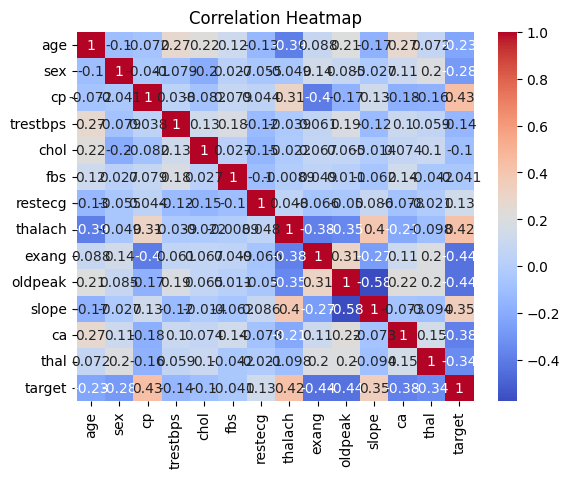

In [3]:
df.info()
df.describe()
df.isnull().sum()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## 📈 Step 4: Split Features and Target


In [5]:
X = df.drop("target", axis=1)
y = df["target"]


## 🧪 Step 5: Split Data into Train and Test Sets


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 🌳 Step 6: Train Decision Tree Classifier


In [7]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



## 🧠 Step 7: Visualize the Decision Tree


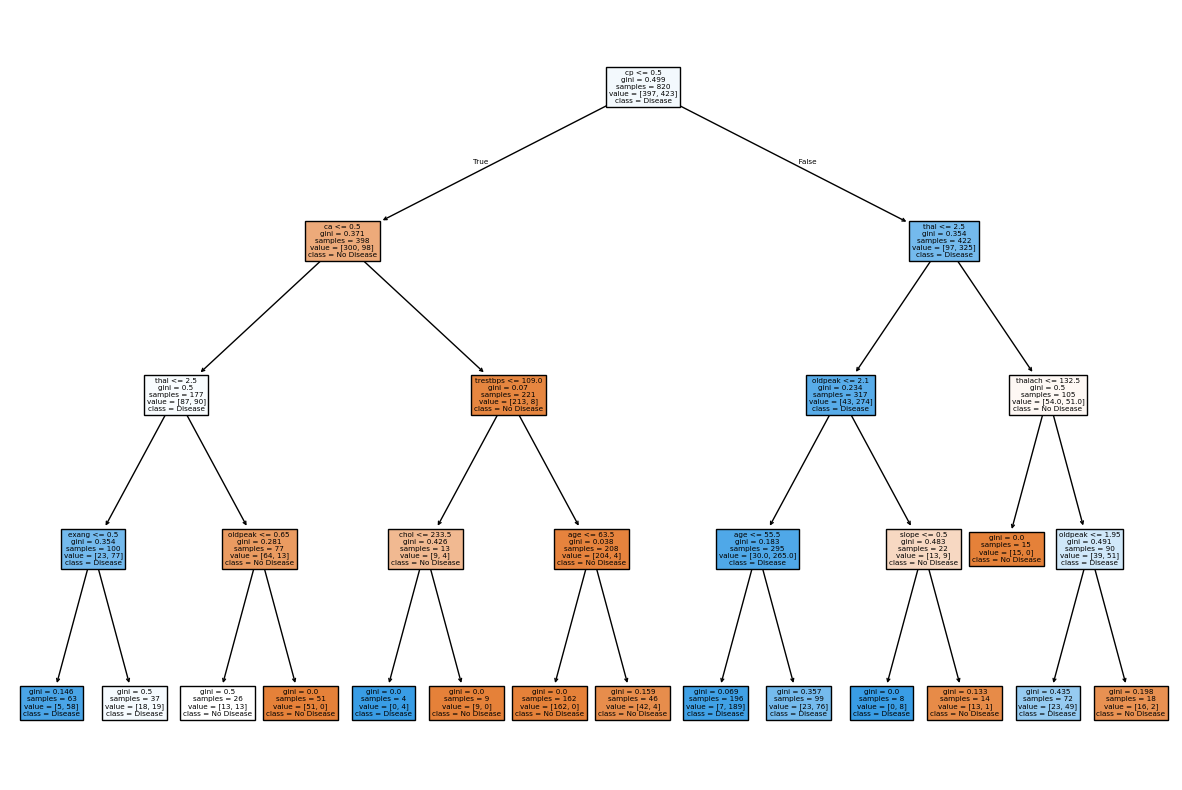

In [8]:
plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.show()


## 🌲 Step 8: Train Random Forest Classifier


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



## 🔍 Step 9: Feature Importance from Random Forest


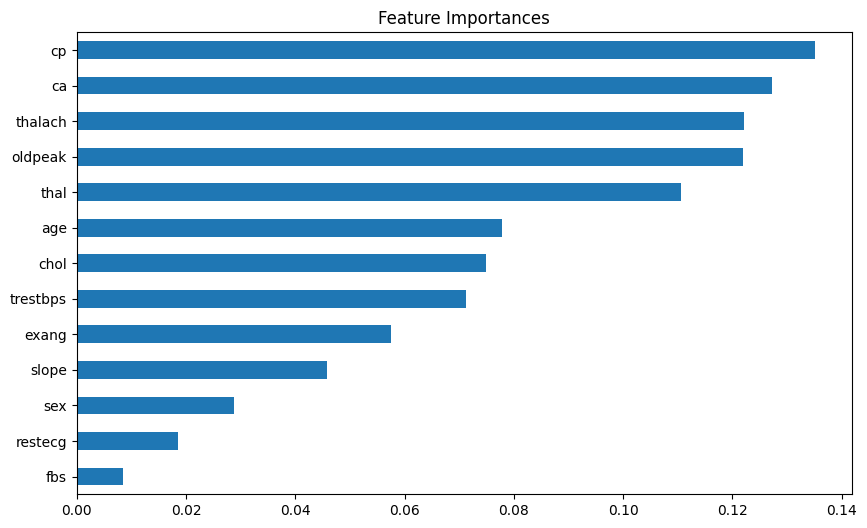

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(10,6), title="Feature Importances")
plt.show()


## 🔁 Step 10: Cross-Validation Score


In [11]:
rf_cv_scores = cross_val_score(rf, X, y, cv=5)
print("Random Forest CV Accuracy:", rf_cv_scores.mean())


Random Forest CV Accuracy: 0.9970731707317073


## 💾 Step 11: Save the Random Forest Model


In [12]:
joblib.dump(rf, "random_forest_heart_model.pkl")


['random_forest_heart_model.pkl']